<a href="https://colab.research.google.com/github/ariefpurnamamuharram/ariefpurnamamuharram.github.io/blob/master/files/W01_23521013_Arief_Purnama_Muharram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week-01 Assignment: employee_data.csv
___

Name: Arief Purnama Muharram<br>
Student number: 23521013

In [ ]:
# Install all of the requirements.
!pip install pandas

In [ ]:
# Connect the Google Colab with the Google Drive account
# so the Colab can access the Drive's contents.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Set Pandas options.
pd.set_option('display.max_columns', None)

# Import the data.
# I place the data in Google Drive's root folder.
df = pd.read_csv('/content/drive/MyDrive/employee_data.csv')

# Print sample of the data.
print('[employee_data.csv]')
print(df.head(10))

print('\n')

# Print summary of the data.
print('[Data Summary]')
print(df.info())

[employee_data.csv]
   number first_name last_name gender  birth_date employment_status  \
0     483     Lenord      Kihn      M  1994-07-01               NaN   
1     478      Palma    Beahan      F  1972-05-06                PE   
2     348     Hebert    Muller      M  1990-09-04                PE   
3     757   Virginia   Ullrich      M  1991-09-23                PE   
4     937       Roby    Hudson      M  1997-01-15               NaN   
5     264      Jaeda   Effertz    NaN  1994-03-21                PE   
6     165    Jalissa  Bogisich      F  1974-01-07                PE   
7     211      Lexie     Robel      M  1997-09-05               NaN   
8     510      Billy    Reilly      M  1977-04-30               NaN   
9     940    Marlana      Moen      F  1979-05-05                CA   

   annual_salary  tax_file_no  
0        64598.0          NaN  
1       124103.0          NaN  
2       100324.0          NaN  
3       144957.0          NaN  
4       137659.0          NaN  
5     

In [ ]:
# Summary
# ----
# After we read the data we can conclude as follows.
# - 'number' column has 0 row with missing value.
# - 'first_name' column has 1 row with missing value.
# - 'last_name' column has 1 row with missing value.
# - 'gender' column has 207 rows with missing value.
# - 'birth_date' column has 1 row with missing value.
# - 'employment_status' has 189 rows with missing value.
# - 'annual_salary' has 1 row with missing value.
# - 'tax_file_no' has 1000 rows with missing value,
#    means all rows in the data does not have 'tax_file_no' value.

## Data preprocessing
___

I'm doing data cleaning to ensure the quality of the data itself.

In [ ]:
# [Drop the 'number' column]
# I think the 'number' column is not important.
# Its seems only show the order of the data inserted.
# Better to remove it.
df = df.drop(['number'], axis=1)

In [ ]:
# [Drop the 'tax_file_no' column]
# All rows doesn't contain 'tax_file_no' value, so better to remove it!
df = df.drop(['tax_file_no'], axis=1)

In [ ]:
# [Is there any duplicated data?]
# I will find the duplicated data by considering the 'first_name', 'last_name',
# 'gender', and 'birth_date' column.
# I'm doing this because I assume that this was employee data, with each 
# employee is unique by its first name, last name, gender, and birth date.
total_duplicated_data = df.duplicated(subset=['first_name', 'last_name', 
                                              'gender', 'birth_date'], 
                                      keep='first').sum()

print('There are ' + str(total_duplicated_data) + 
      ' duplicated rows in the data!')

There are 0 duplicated rows in the data!


In [ ]:
# No duplicate data, so none of the rows need to be dropped.

In [ ]:
# [Dealing with the missing values]
# Step 1: Remove empty rows. 
df.dropna(how='all', inplace=True)

# Step 2: Fill empty 'gender' column with 'U' code (means 'Unknown')
df['gender'].fillna(value='U', inplace=True)

# Step 3: Fill empty 'employment_status' column with 'U' code (means 'Unknown')
df['employment_status'].fillna(value='U', inplace=True)

# Print current data info.
print(df.info())


<class 'pandas.core.frame.DataFrame'>
Int64Index: 999 entries, 0 to 999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   first_name         999 non-null    object 
 1   last_name          999 non-null    object 
 2   gender             999 non-null    object 
 3   birth_date         999 non-null    object 
 4   employment_status  999 non-null    object 
 5   annual_salary      999 non-null    float64
dtypes: float64(1), object(5)
memory usage: 54.6+ KB
None


In [ ]:
# ['employee_name' column]
# I concatenate 'first_name' and 'last_name' column in order to get 'employee_name'.
df['employee_name'] = df['first_name'] + ' ' + df['last_name']

# I rearrange the index so the 'emplyee_name' column is after the 'last_name' column.
df = df.reindex(['first_name', 'last_name', 'employee_name', 'gender', 
                 'birth_date', 'employment_status', 'annual_salary'], axis=1)
print('[employee_data.csv]')
print(df.head(5))

[employee_data.csv]
  first_name last_name     employee_name gender  birth_date employment_status  \
0     Lenord      Kihn       Lenord Kihn      M  1994-07-01                 U   
1      Palma    Beahan      Palma Beahan      F  1972-05-06                PE   
2     Hebert    Muller     Hebert Muller      M  1990-09-04                PE   
3   Virginia   Ullrich  Virginia Ullrich      M  1991-09-23                PE   
4       Roby    Hudson       Roby Hudson      M  1997-01-15                 U   

   annual_salary  
0        64598.0  
1       124103.0  
2       100324.0  
3       144957.0  
4       137659.0  


In [ ]:
# [Casefolding in 'employee_name' column]
# Im doing the "title" casefolding operation in the 'employee_name' column in order
# to make sure that first character of each word is uppercase while the remaining 
# is lowercase.
df['employee_name'] = df['employee_name'].str.title()

print('[employee_data.csv]')
print(df.head(5))

[employee_data.csv]
  first_name last_name     employee_name gender  birth_date employment_status  \
0     Lenord      Kihn       Lenord Kihn      M  1994-07-01                 U   
1      Palma    Beahan      Palma Beahan      F  1972-05-06                PE   
2     Hebert    Muller     Hebert Muller      M  1990-09-04                PE   
3   Virginia   Ullrich  Virginia Ullrich      M  1991-09-23                PE   
4       Roby    Hudson       Roby Hudson      M  1997-01-15                 U   

   annual_salary  
0        64598.0  
1       124103.0  
2       100324.0  
3       144957.0  
4       137659.0  


In [ ]:
# ['birth_year' column]
# Get birth year by its birth date.
df['birth_year'] = (pd.to_datetime(df['birth_date'], errors='raise')).dt.year

# I rearrange the index so the 'birth_year' column is after the 'birth_date' column.
df = df.reindex(['first_name', 'last_name', 'employee_name', 'gender', 
                 'birth_date', 'birth_year', 'employment_status', 
                 'annual_salary'], axis=1)
print('[employee_data.csv]')
print(df.head(5))

[employee_data.csv]
  first_name last_name     employee_name gender  birth_date  birth_year  \
0     Lenord      Kihn       Lenord Kihn      M  1994-07-01        1994   
1      Palma    Beahan      Palma Beahan      F  1972-05-06        1972   
2     Hebert    Muller     Hebert Muller      M  1990-09-04        1990   
3   Virginia   Ullrich  Virginia Ullrich      M  1991-09-23        1991   
4       Roby    Hudson       Roby Hudson      M  1997-01-15        1997   

  employment_status  annual_salary  
0                 U        64598.0  
1                PE       124103.0  
2                PE       100324.0  
3                PE       144957.0  
4                 U       137659.0  


In [ ]:
# [Sort the data]
# Sort the data by the 'employee_name' column in an ascending order.
df.sort_values(by=['employee_name'], axis=0, ascending=True, inplace=True)
print('[employee_data.csv]')
print(df.head(5))

[employee_data.csv]
    first_name last_name     employee_name gender  birth_date  birth_year  \
354      Abbey     Fahey       Abbey Fahey      F  1982-08-27        1982   
401     Abbott    Rippin     Abbott Rippin      F  1984-03-11        1984   
611        Abe   Schultz       Abe Schultz      M  1994-11-15        1994   
554       Abie      Kuhn         Abie Kuhn      F  1981-09-13        1981   
959    Abraham  Botsford  Abraham Botsford      M  1990-06-01        1990   

    employment_status  annual_salary  
354                 U       124621.0  
401                PE        93348.0  
611                CA        71706.0  
554                PE       109730.0  
959                 U        80828.0  


## Data visualization
___


In [ ]:
# [Count 'employee_name' by its 'birth_year']
print('[Total Employee by Its Birth Year]')
print('-----------------------------------')
print(df.groupby(['birth_year']).size().reset_index(name='count'))

[Total Employee by Its Birth Year]
-----------------------------------
    birth_year  count
0         1970     32
1         1971     33
2         1972     31
3         1973     35
4         1974     30
5         1975     40
6         1976     28
7         1977     33
8         1978     34
9         1979     35
10        1980     34
11        1981     38
12        1982     39
13        1983     25
14        1984     35
15        1985     23
16        1986     31
17        1987     33
18        1988     34
19        1989     31
20        1990     43
21        1991     37
22        1992     33
23        1993     32
24        1994     48
25        1995     31
26        1996     32
27        1997     37
28        1998     28
29        1999     24


In [ ]:
# [Show group of the oldest employee]
print(df.groupby(['birth_year']).get_group(df.groupby(['birth_year']).size()
.index.min())[['employee_name', 'birth_year']])

        employee_name  birth_year
841      Adella Hintz        1970
593      Alston Davis        1970
344     Amarion Tromp        1970
765    Aurora Fritsch        1970
462    Bobbie Kessler        1970
957      Bryce Beatty        1970
30    Desmond Pfeffer        1970
326      Dulcie Lemke        1970
464     Erling Nienow        1970
826        Freda Dare        1970
441    Galilea Waters        1970
42   Hildred Mckenzie        1970
41      Jaiden Hirthe        1970
933    Jeannine Hyatt        1970
773       Jory Waters        1970
634  Joselyn Schmeler        1970
961   Karrie Prosacco        1970
695     Keeley Conroy        1970
876     Kirby Schmitt        1970
128      Luella Tromp        1970
918     Mikeal Deckow        1970
661      Misti Hammes        1970
843       Nelly Kiehn        1970
668        Ocie Lakin        1970
786    Rico Wilderman        1970
849      Romeo Kohler        1970
174        Semaj Rowe        1970
218  Shanelle Rolfson        1970
439    Sherrie

In [ ]:
# [Show group of the youngest employee]
print(df.groupby(['birth_year']).get_group(df.groupby(['birth_year']).size()
.index.max())[['employee_name', 'birth_year']])

          employee_name  birth_year
846         Alfred Wiza        1999
225   Alwilda Lueilwitz        1999
815           Cory Funk        1999
724       Denisha Price        1999
448     Dolores Trantow        1999
228    Evette Marquardt        1999
685      Gerald Pfeffer        1999
35      Jaelynn Corkery        1999
755      Jedidiah Zieme        1999
580  Kathyrn Balistreri        1999
691        Meryl Wunsch        1999
295     Mozelle Ullrich        1999
330           Odin Metz        1999
516      Penelope Crona        1999
942     Ross Konopelski        1999
952       Santana Jones        1999
134  Syreeta Altenwerth        1999
273       Toma Leuschke        1999
165      Travon Schmitt        1999
935       Truman Hansen        1999
744   Ursula Wintheiser        1999
72      Vassie Turcotte        1999
883         West Blanda        1999
556        Zelpha White        1999


In [ ]:
# [Get employee percentage by its gender]
print("Gender percentage")
print("-------------------")
print("Male employee\t", ":", 
      (round((df.groupby('gender').size()/df['gender'].count())*100, 1))['M'], 
      "%")
print("Female employee\t", ":", 
      (round((df.groupby('gender').size()/df['gender'].count())*100, 1))['F'], 
      "%")
print("Unknown\t\t", ":", 
      (round((df.groupby('gender').size()/df['gender'].count())*100, 1))['U'], 
      "%")

Gender percentage
-------------------
Male employee	 : 41.4 %
Female employee	 : 37.9 %
Unknown		 : 20.6 %


In [ ]:
# ['annual_salary' statistics description]
# Round it to 2 decimal place.
print(round(df['annual_salary'].describe(), 2))

count       999.00
mean     102017.20
std       27567.85
min       55003.00
25%       77720.00
50%      101133.00
75%      125829.00
max      149999.00
Name: annual_salary, dtype: float64


In [ ]:
# [Get employee name with highest annual salary]
print(df.groupby(['annual_salary']).get_group(df.max()['annual_salary']))

    first_name last_name    employee_name gender  birth_date  birth_year  \
665     Vergie  Tremblay  Vergie Tremblay      F  1987-12-09        1987   

    employment_status  annual_salary  
665                CA       149999.0  


In [ ]:
# [Get employee name with lowest annual salary]
print(df.groupby(['annual_salary']).get_group(df.min()['annual_salary']))

    first_name last_name  employee_name gender  birth_date  birth_year  \
373    Mustafa     Emard  Mustafa Emard      M  1972-03-16        1972   

    employment_status  annual_salary  
373                PE        55003.0  


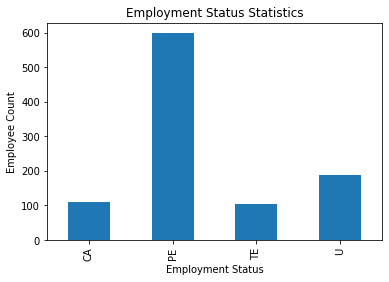

In [ ]:
# [Plotting the 'employment_status' column]
df.groupby(['employment_status']).size().plot(kind='bar', 
                                              xlabel='Employment Status', 
                                              ylabel='Employee Count', 
                                              title='Employment Status Statistics')